# Machine Learning Models
**This section houses the machine learning models we will use to predict QB fantasy scores. Models include...**
1. Linear Regression
2. Lasso Regression
3. Ridge Regression
4. Random Forest
5. K Nearest Neighbors
6. Support Vector Regression (Kernel)

In [9]:
import os
import numpy as np
import pandas as pd
import statistics

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.kernel_approximation import RBFSampler
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, cross_val_score, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import max_error
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR

import seaborn as sns
import matplotlib.pyplot as plt

### Importing Data and Adding Fantasy Points

In [11]:
# Imports data from Sentiment Analysis
url = 'https://raw.githubusercontent.com/anjalinambudiri-jpg/NFL-Sentiment-Analysis/refs/heads/main/sentimentfolder/article_sentiment_model_results'
df = pd.read_csv(url)

# Reconfigures data to have QB name and each of the 3 sentiment types as separate columns for said QB
df_concise = df.drop(columns = ['Prob_Negative', 'Prob_Neutral', 'Prob_Positive', 'Overall_QB_Average'])
df_final = df_concise.pivot_table(index='QB Name', columns='Subset Label', values='Sentiment_Score', aggfunc='first').reset_index()
df_final.columns.name = None

# Makes index QB Names
df_final.set_index('QB Name', inplace=True)

# Adds Non-PPR per game fantasy points data from 2024 and 2025
# 2024 data from CBS b/c ESPN lacks 2024 data: https://www.cbssports.com/fantasy/football/stats/QB/2024/season/stats/nonppr/
df_final['2024 Fantasy Points'] = [21.0, 15.1, 14.4, 17.2, 22.5, 22.6, 18.6, 29.2, 15.3, 19.9]
# 2025 data from https://fantasy.espn.com/football/leaders?lineupSlot=0&scoringPeriodId=0&statSplit=lastSeason&leagueFormatId=1 
df_final['2025 Fantasy Points'] = [17.9, 13.6, 14.9, 11.6, 18.7, 17.5, 17.9, 16.5, 20.6, 20.3]

# Separating Features and target
Features = ['In-Season', 'Offense'] # Excluding 2024 as it worsens model accuracy
X = df_final[Features].values
y = df_final['2025 Fantasy Points'].values

df_final

,In-Season,Offense,Player,2024 Fantasy Points,2025 Fantasy Points
QB Name,,,,,
Bo Nix,0.356108,0.100487,0.139233,21.0,17.9
Bryce Young,0.276366,0.163726,0.067309,15.1,13.6
CJ Stroud,0.025620,0.217719,0.241398,14.4,14.9
Geno Smith,0.095094,0.257169,0.220110,17.2,11.6
Jalen Hurts,0.423909,0.363172,0.567466,22.5,18.7
Jared Goff,0.436252,0.344462,0.416114,22.6,17.5
Justin Herbert,0.315421,0.334155,0.343001,18.6,17.9
Lamar Jackson,-0.007019,0.214719,0.289899,29.2,16.5
Matthew Stafford,0.167443,-0.037001,-0.013875,15.3,20.6


### Exploratory Data Analysis

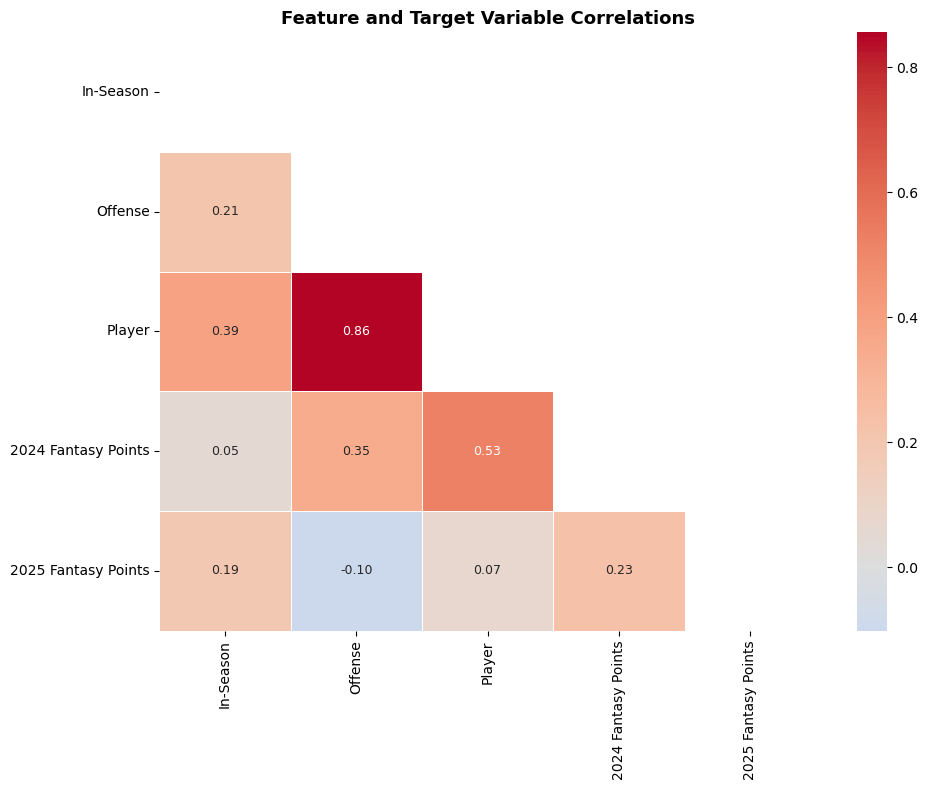

In [13]:
# Making a correlational heat map to see what variables to hone in on
fig, ax = plt.subplots(figsize=(10, 8))

corr = df_final.corr() # computes correlational coefficients
mask = np.triu(np.ones_like(corr, dtype=bool))  # creates mask for heatmap to use

# overlays heatmap corresponding to strength of correlation (blue = negative correlation, red = positive correlation)
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
    center=0, linewidths=0.5, ax=ax, annot_kws={'size': 9}
)

# formatting and such
ax.set_title('Feature and Target Variable Correlations', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('exploratory.png')
plt.show()

### Setting up the K-Fold

In [14]:
# Configures cross validation splitter for k-folds (10 folds)
kf = KFold(n_splits=10, shuffle=True, random_state=42)

### Experiment Class with Data Visualization

In [15]:
class Regression_Experiment:
    """
    Tools for evaluating each model across all 10 folds
    Metrics are aggregated across folds and returned for comparison
    """

    def __init__(self, X, y, kf, df_final):
        self.X = X
        self.y = y
        self.kf = kf
        self.df_final = df_final
        self.results = {}
        self.pipeline = {}

    def evaluate(self, name, pipeline):
        """
        Runs Kfold cross validation method and stores MSE, RMSE, and relative error
        Parameters:
            name: string used as display name and as dictionary key for self.results and self.pipelines
            pipeline: fitted sklearn pipeline using StandardScaler model
        """

        # Computes accuracy scores for each model  using cross_val_score
        mse_scores = -cross_val_score(pipeline, self.X, self.y, cv=self.kf, scoring='neg_mean_squared_error')
        rmse_scores = np.sqrt(mse_scores)
        rel_err_pct = (rmse_scores / np.mean(y)) * 100

        # Computes Max Error
        y_pred = cross_val_predict(pipeline, self.X, self.y, cv=self.kf)
        max_err = max_error(self.y, y_pred)

        # Stores results for later
        self.pipeline[name] = pipeline
        
        self.results[name] = {'Avg MSE':mse_scores.mean(), 'Avg RMSE':rmse_scores.mean(), 'Max Error':max_err, 'Avg Rel Error (%)':rel_err_pct.mean()}

        # Prints per fold results
        print(f"\n{name}")
        print(f"MSE per fold:{np.round(mse_scores, 3)}")
        print(f"RMSE per fold:{np.round(rmse_scores, 3)}")
        print(f"Rel Error % per fold:{np.round(rel_err_pct, 2)}")
        print(f" *** Avg MSE:  {mse_scores.mean():.4f}  |  Avg RMSE: {rmse_scores.mean():.4f}"
              f"  |  Max Error: {max_err:.4f}  |  Avg Rel Err: {rel_err_pct.mean():.2f}%")

    def summary(self):
        """
        Returns a dataframe of all models sorted by Avg RMSE 
        """
        return (pd.DataFrame(self.results).T.sort_values('Avg RMSE').rename_axis('Model'))


    def plot_results(self):
        """
        Creates 2 visuals based on best model from each model type
        Visualization 1: Compares accuracies (RMSE, Max Error, Relative Error)
        Visualization 2: Actual vs Predicted results for best SVR and KNN for each QB
        """
        qb_names = self.df_final.index.tolist()
        summary  = self.summary()  # already sorted by Avg RMSE
    
        # Some nice colors to make the graphs look solid
        PALETTE = {
            'Linear Regression': '#4E79A7',
            'Random Forest': '#59A14F',
            'Ridge': '#F28E2B',
            'Lasso': '#B07AA1',
            'KNN': '#76B7B2',
            'SVR': '#E15759',
            'Actual': '#BAB0AC',
        }
    
        def family_color(name):
            """ This mini-function allows us to return the desired color for each model we test for consistency """
            for key in PALETTE:
                if name.startswith(key):
                    return PALETTE[key]
            return '#888888'
    
        # Identifies best model per family (most accurate set of hyperparameters)
        families  = ['Linear Regression', 'Random Forest', 'Ridge', 'Lasso', 'KNN', 'SVR']
        best_models = {}
        for fam in families:
            candidates = [(name, row) for name, row in self.results.items() if name.startswith(fam)]
            if candidates:
                best_name, best_row = min(candidates, key=lambda x: x[1]['Avg RMSE'])
                best_models[fam] = (best_name, best_row)
    
        # visualization 1: Best model per family using metric comparison
        metrics = ['Avg RMSE', 'Max Error', 'Avg Rel Error (%)']
        fam_names = list(best_models.keys())
        n_models = len(fam_names)
        n_metrics = len(metrics)
        width = 0.13
        x_pos = np.arange(n_metrics)

        # Actually plotting the figure using matplotlib
        fig, ax = plt.subplots(figsize=(12, 6))
        for i, fam in enumerate(fam_names):
            name, row = best_models[fam]
            vals = [row[m] for m in metrics]
            offset = (i - n_models / 2 + 0.5) * width
            bars = ax.bar(x_pos + offset, vals, width, label=name, color=family_color(fam), alpha=0.88)
            for bar, val in zip(bars, vals):
                ax.text(bar.get_x() + bar.get_width() / 2,
                        bar.get_height() + 0.06,
                        f'{val:.2f}', ha='center', va='bottom', fontsize=7)

        # Labeling everything nicely
        ax.set_title('Model Comparison', fontsize=14, fontweight='bold')
        ax.set_xticks(x_pos)
        ax.set_xticklabels(metrics, fontsize=11)
        ax.set_ylabel('Error (lower is better)')
        ax.legend(loc='best', fontsize=8)
        ax.grid(axis='y', alpha=0.25)
        plt.tight_layout()
        plt.savefig('viz1_model_comparison.png', dpi=150, bbox_inches='tight')
        plt.show()
    
        # visualization 2: Best SVR vs Best KNN vs Actual Fantasy Points
        best_svr_name, _ = best_models['SVR']
        best_knn_name, _ = best_models['KNN']

        # Runs SVR and KNN models again and stores results for each QB
        svr_pred = cross_val_predict(self.pipeline[best_svr_name], self.X, self.y, cv=self.kf)
        knn_pred = cross_val_predict(self.pipeline[best_knn_name], self.X, self.y, cv=self.kf)

        # Formatting
        x_pos2 = np.arange(len(qb_names))
        width2 = 0.25

        # Creating the graph itself using matplotlib
        fig, ax = plt.subplots(figsize=(14, 6))
        ax.bar(x_pos2 - width2,  self.y,   width2, label='Actual', color=PALETTE['Actual'], alpha=0.9)
        ax.bar(x_pos2, svr_pred, width2, label=best_svr_name, color=PALETTE['SVR'], alpha=0.88)
        ax.bar(x_pos2 + width2,  knn_pred, width2, label=best_knn_name, color=PALETTE['KNN'], alpha=0.88)

        # Setting labels
        ax.set_title('Actual vs Predicted 2025 Fantasy Points: Best Kernel(SVR) & KNN Models Compared', fontsize=14, fontweight='bold')
        ax.set_xticks(x_pos2)
        ax.set_xticklabels(qb_names, rotation=45, ha='right', fontsize=9)
        ax.set_ylim(0, 28)
        ax.set_ylabel('Fantasy Points')
        ax.legend()
        ax.grid(axis='y', alpha=0.25)
    
        plt.tight_layout()
        plt.savefig('viz2_svr_knn_predictions.png', dpi=150, bbox_inches='tight')
        plt.show()
            

### Standardized Feature Scaling with StandardScaler Pipeline

In [16]:
def make_pipeline(model):
    """
    Wraps model in a StandardScaler pipeline (seems best for ridge and lasso regression)
    """
    return Pipeline([('scaler', StandardScaler()), ('model', model)])

### Run Models & Print Results

In [18]:
# Sets up fresh experiment object to run tests
exp = Regression_Experiment(X, y, kf, df_final)

# Linear Regression and Random Forest are run without hyperparameter modifications
exp.evaluate('Linear Regression', make_pipeline(LinearRegression()))
exp.evaluate('Random Forest', make_pipeline(RandomForestRegressor(n_estimators=100, random_state=42)))


# These next 4 models (LASSO, Ridge, KNN, SVR) are run with a variety of hyperparameters to find the best combination
for alpha in [0.01, 0.1, 1.0, 10.0, 100.0]:
    exp.evaluate(f'Ridge (α={alpha})', make_pipeline(Ridge(alpha=alpha)))

for alpha in [0.01, 0.05, 0.1, 0.5, 1.0]:
    exp.evaluate(f'Lasso (α={alpha})', make_pipeline(Lasso(alpha=alpha, max_iter=10000)))

for k in [2, 3, 4, 5]:
    exp.evaluate(f'KNN (k={k})', make_pipeline(KNeighborsRegressor(n_neighbors=k)))

for C, eps in [(0.1, 0.1), (1.0, 0.5), (10.0, 0.1), (100.0, 0.5)]:
    exp.evaluate(f'SVR (C={C}, ε={eps})', make_pipeline(SVR(kernel='rbf', C=C, epsilon=eps)))

# Comparison table printed at the end to find best models
print('\n *Model Comparison (Sorted by Avg RMSE)*')
print(exp.summary().to_string(float_format='{:.4f}'.format))


Linear Regression
MSE per fold:[5.2240e+01 2.0263e+01 3.7000e-02 0.0000e+00 1.8300e-01 3.3470e+00
 4.0867e+01 4.8700e+00 3.3639e+01 1.3680e+00]
RMSE per fold:[7.228 4.501 0.192 0.009 0.428 1.829 6.393 2.207 5.8   1.17 ]
Rel Error % per fold:[42.64 26.56  1.13  0.05  2.52 10.79 37.72 13.02 34.22  6.9 ]
 *** Avg MSE:  15.6813  |  Avg RMSE: 2.9756  |  Max Error: 7.2277  |  Avg Rel Err: 17.56%

Random Forest
MSE per fold:[33.861 10.189  0.546  7.017  0.217  1.855 28.048  1.212 17.581  0.465]
RMSE per fold:[5.819 3.192 0.739 2.649 0.466 1.362 5.296 1.101 4.193 0.682]
Rel Error % per fold:[34.33 18.83  4.36 15.63  2.75  8.04 31.24  6.5  24.74  4.02]
 *** Avg MSE:  10.0991  |  Avg RMSE: 2.5499  |  Max Error: 5.8190  |  Avg Rel Err: 15.04%

Ridge (α=0.01)
MSE per fold:[5.2194e+01 2.0252e+01 3.7000e-02 0.0000e+00 1.8200e-01 3.3490e+00
 4.0811e+01 4.8690e+00 3.3641e+01 1.3680e+00]
RMSE per fold:[7.225e+00 4.500e+00 1.930e-01 7.000e-03 4.260e-01 1.830e+00 6.388e+00
 2.207e+00 5.800e+00 1.169e+00

### Some Useful Data Visualizations

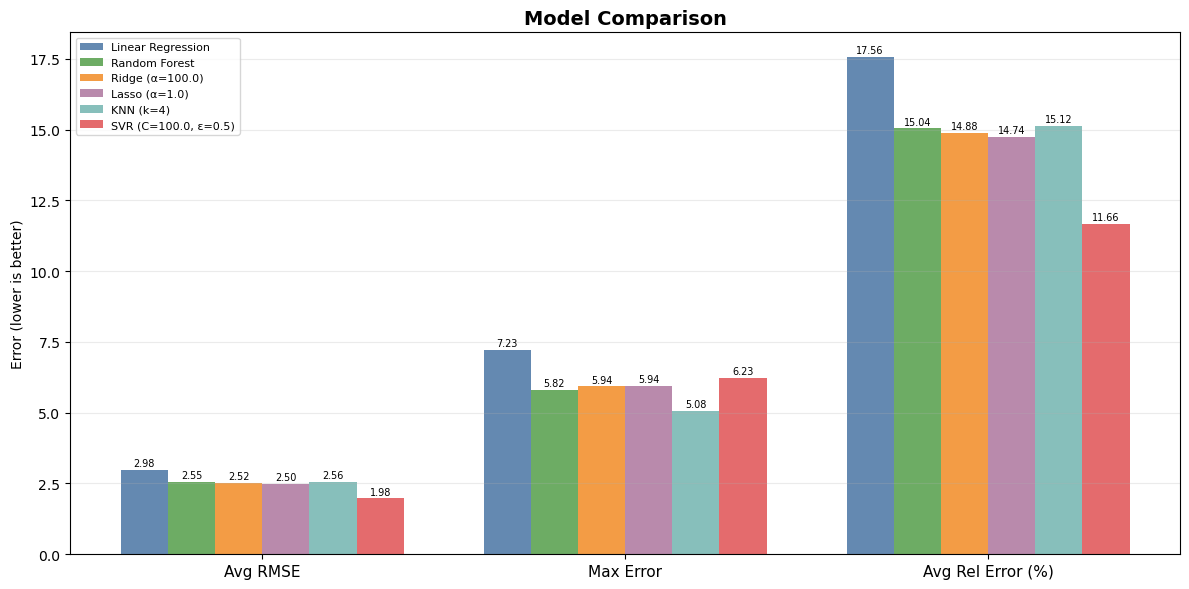

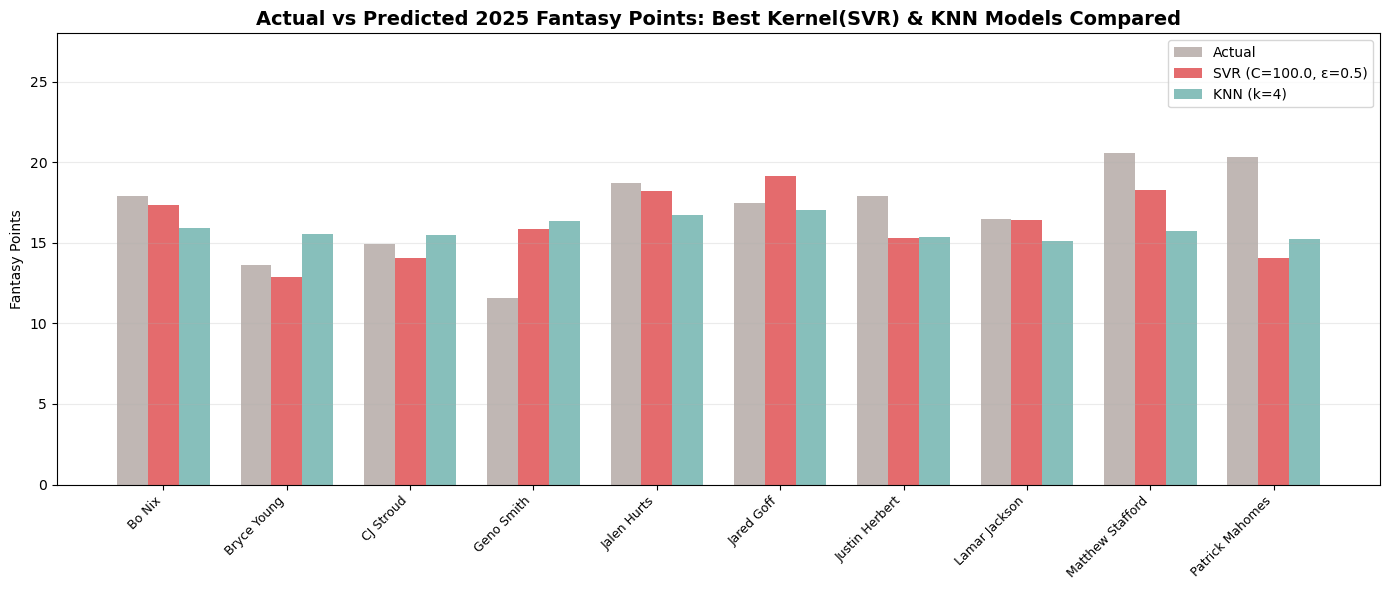

In [20]:
# Prints the two visuals we defined earlier
exp.plot_results()

In [21]:
# Calculates base standard deviation for Fantasy Points
std = statistics.pstdev(df_final['2025 Fantasy Points'])
print(std)

2.7196507128673715
